# Car Insurance Claim Prediction

## Project Overview

This notebook follows a clean and objective workflow to build a model that **predicts whether a car insurance customer will make a claim** on their insurance during the policy period.

The main steps include:

* Loading the dataset  
* Exploring the data  
* Cleaning and preparing the features  
* Encoding categorical variables  
* Training 2 machine learning models  
* Evaluating performance  
* Interpreting results

The goal is to keep the process clear, organized, and accessible while still being professional.

## Importing the Libraries

In this step, I load the Python libraries that I will use throughout the project.  
They include tools for data handling, visualization, and machine learning.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Loading the Dataset

Here I load the car insurance dataset from a local CSV file called 'car_insurance.csv'.  
After that, I take a quick look at the first rows and the structure of the data to understand what I'm working with.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car_insurance.csv to car_insurance.csv


In [ ]:
# load the dataset
car = pd.read_csv('car_insurance.csv')
car.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


## Understanding the Data

To prepare de data, it's important to understand the dataset.  
Here I check:
* the column types  
* whether there are missing values  
* basic statistical information

In [ ]:
car.info()
car.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.00,10000.00,10000.0,9018.00,10000.00,10000.0,10000.00,10000.00,9043.00,10000.00,10000.00,10000.00,10000.00
mean,500521.91,1.49,0.5,0.52,0.70,0.5,0.69,19864.55,11697.00,1.48,0.24,1.06,0.31
std,290030.77,1.03,0.5,0.14,0.46,0.5,0.46,18915.61,2818.43,2.24,0.55,1.65,0.46
min,101.00,0.00,0.0,0.05,0.00,0.0,0.00,10238.00,2000.00,0.00,0.00,0.00,0.00
25%,249638.50,1.00,0.0,0.42,0.00,0.0,0.00,10238.00,10000.00,0.00,0.00,0.00,0.00
50%,501777.00,1.00,0.0,0.53,1.00,0.0,1.00,10238.00,12000.00,0.00,0.00,0.00,0.00
75%,753974.50,2.00,1.0,0.62,1.00,1.0,1.00,32765.00,14000.00,2.00,0.00,2.00,1.00
max,999976.00,3.00,1.0,0.96,1.00,1.0,1.00,92101.00,22000.00,22.00,6.00,15.00,1.00


## Data Preparation

Before modeling, I will prepare the dataset by performing the following steps:

1. **Handling missing data:**  
   The numerical columns `credit_score` and `annual_mileage` contain missing values.  
   These will be imputed using the **median**, which is appropriate for normally distributed numeric variables.

2. **Encoding Categorical Columns**
  Some columns contain string labels. They need to be converted into numeric values.

3. **Selecting the target and features:**  
   The target variable for this project is `outcome`.  
   The `id` column is removed because it does not contain predictive information.

4. **Validating data types:**  
   Ensuring that all feature columns are numerical and ready for modeling.

After this preparation step, the dataset will be clean and suitable for model training.


## Handling Missing Values

I checked which columns contain missing values using car.info().
The dataset has missing values in two numerical features:

* **credit_score**
* **annual_mileage**


Since both are numerical and the amount of missing data is small compared to the full dataset, I decided to fill the missing values using the median of each column.
I chose the median because it is a simple and reliable strategy that works well when the data may have outliers.




In [ ]:
# imput missing data to the mean
car['credit_score'] = car['credit_score'].fillna(car['credit_score'].median())
car['annual_mileage'] = car['annual_mileage'].fillna(car['annual_mileage'].median())

# check missing values again
print(f"The DataFrame has {car.isna().any().sum()} missing values.")

The DataFrame has 0 missing values.


## Encoding Categorical Variables

Some columns are stored as text (like vehicle type or age ranges).  
Machine learning models cannot work with strings, so I convert these features into numeric form using one-hot encoding.

This creates new binary columns for each category.

I will apply one-hot encoding to all object columns and drop the original text columns afterwards.

In [ ]:
# One-Hot Encoding for categorical columns
cat_cols = car.select_dtypes(include='object').columns

car_encoded = pd.get_dummies(car, columns=cat_cols, drop_first=True)

car_encoded.head()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,...,driving_experience_10-19y,driving_experience_20-29y,driving_experience_30y+,education_none,education_university,income_poverty,income_upper class,income_working class,vehicle_year_before 2015,vehicle_type_sports car
0,569520,3,0,0.629027,1.0,0.0,1.0,10238,12000.0,0,...,False,False,False,False,False,False,True,False,False,False
1,750365,0,1,0.357757,0.0,0.0,0.0,10238,16000.0,0,...,False,False,False,True,False,True,False,False,True,False
2,199901,0,0,0.493146,1.0,0.0,0.0,10238,11000.0,0,...,False,False,False,False,False,False,False,True,True,False
3,478866,0,1,0.206013,1.0,0.0,1.0,32765,11000.0,0,...,False,False,False,False,True,False,False,True,True,False
4,731664,1,1,0.388366,1.0,0.0,0.0,32765,12000.0,2,...,True,False,False,True,False,False,False,True,True,False


## Preparing the Features for Modeling

Here I separate the target variable `outcome` from the rest of the dataset.  
I also exclude the `id` column, since it does not provide useful information for prediction.

In [ ]:
# define target and feature columns
target = "outcome"
features = car_encoded.columns.drop(["outcome", "id"])

print("Selected feature columns:")
features



Selected feature columns:


Index(['age', 'gender', 'credit_score', 'vehicle_ownership', 'married',
       'children', 'postal_code', 'annual_mileage', 'speeding_violations',
       'duis', 'past_accidents', 'driving_experience_10-19y',
       'driving_experience_20-29y', 'driving_experience_30y+',
       'education_none', 'education_university', 'income_poverty',
       'income_upper class', 'income_working class',
       'vehicle_year_before 2015', 'vehicle_type_sports car'],
      dtype='object')

In [ ]:
# check data types
car_encoded[features].dtypes

,0
age,int64
gender,int64
credit_score,float64
vehicle_ownership,float64
married,float64
children,float64
postal_code,int64
annual_mileage,float64
speeding_violations,int64
duis,int64


## Train/Test Split

To evaluate the performance of the models, the dataset will be divided into:

- **Training set (80%)**: used to fit the model  
- **Test set (20%)**: used to evaluate how well the model generalizes

Splitting the data prevents overfitting and ensures a fair performance check.


In [ ]:
# train/test split
X = car_encoded[features]
y = car_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

X_train.shape, X_test.shape

((8000, 21), (2000, 21))

### Model Training

Now that the dataset is cleaned and the training/testing split is ready, I can start building the machine learning models.

I will experiment 2 options:

- **Logistic Regression**: a simple and interpretable baseline model  
- **Random Forest**: more flexible and able to capture non-linear patterns  

The goal is not to achieve the perfect score, but to compare how these 2 models behave on the same data. After training, I will evaluate their performance on the test set.


In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, solver="liblinear")
log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


## Model Evaluation

With the models trained, the next step is to evaluate their performance on the test set.
Here, I use 3 main components to understand model quality:

- **Accuracy**: proportion of correct predictions
- **Confusion Matrix**: shows how predictions are distributed across classes
- **Classification Report**: precision, recall, and F1-score for a more detailed view

These metrics together give a solid overview of how well each model handles the classification task.



In [ ]:
# Predictions
log_preds = log_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Accuracy
log_acc = accuracy_score(y_test, log_preds)
rf_acc = accuracy_score(y_test, rf_preds)

print("Logistic Regression Accuracy:", round(log_acc, 4))
print("Random Forest Accuracy:", round(rf_acc, 4))

Logistic Regression Accuracy: 0.803
Random Forest Accuracy: 0.823


## Confusion Matrices

The confusion matrices show the counts of true negatives, false positives, false negatives, and true positives.
They help us see where each model makes mistakes.


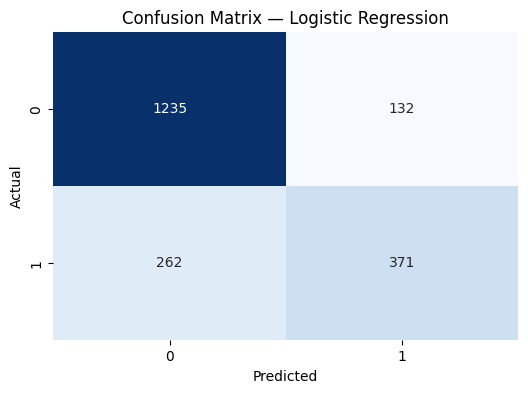

[[1235  132]
 [ 262  371]]


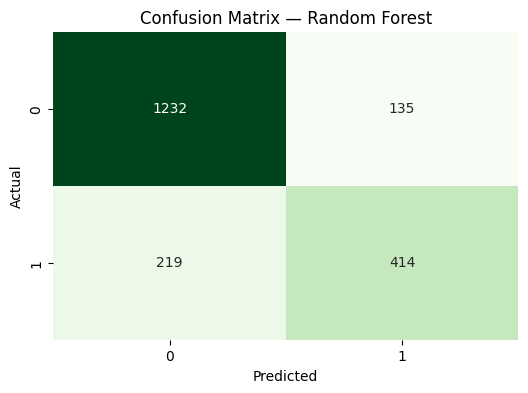

[[1232  135]
 [ 219  414]]


In [ ]:
# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, log_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(confusion_matrix(y_test, log_preds))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(confusion_matrix(y_test, rf_preds))


### Classification Reports

Below are the precision, recall, and F1-score for each model.  
These metrics are especially important when the classes are imbalanced.

In [ ]:
# Classification Reports
print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, log_preds))

print("\nClassification Report - Random Forest:")
print(classification_report(y_test, rf_preds))


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1367
         1.0       0.74      0.59      0.65       633

    accuracy                           0.80      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.80      0.80      0.80      2000


Classification Report - Random Forest:
              precision    recall  f1-score   support

         0.0       0.85      0.90      0.87      1367
         1.0       0.75      0.65      0.70       633

    accuracy                           0.82      2000
   macro avg       0.80      0.78      0.79      2000
weighted avg       0.82      0.82      0.82      2000



## Interpretation of Results

### Accuracy
* Logistic Regression: **0.803**  
* Random Forest: **0.8245**

The Random Forest model performed slightly better overall, showing higher accuracy and stronger results in most metrics.

### Logistic Regression
* Performs well for class 0 (no claim)
* Struggles more with class 1 (claim), with recall around 0.59
* This means it misses some cases where a claim actually happens

### Random Forest
* Strong performance on both classes
* Better recall for class 1 (0.65), which is important if the goal is to not miss potential claims
* Shows the best overall balance between precision and recall

### General Conclusion
Random Forest is a better model for this dataset, offering more reliable predictions and capturing more claim cases without losing too much accuracy.  
Logistic Regression is still useful as a simple and quick baseline model.


## Final Thoughts

This project explored a simple workflow for predicting car insurance claims:

* Data loading and exploration  
* Cleaning and handling missing values  
* Encoding categorical variables  
* Training baseline models  
* Comparing performance  

The Random Forest model gave the best results, but there is room for improvement, such as:

* Trying additional models (e.g., Gradient Boosting, LightGBM)
* Feature engineering (grouping ages, income categories, etc.)
* Hyperparameter tuning
* Balancing the dataset if necessary

Even though this is a relatively simple project, it already shows how machine learning can support insurance risk assessment in a practical way.
